# 30 — Regime Analysis

Week 7, Day 1–2. We classify the backtest period (1985–2024) into market regimes to understand *when* the factor-neutral RV strategy earns money and *when* it struggles.

## Three regime dimensions

**1. PC1 realized volatility** — PC1 is the level factor (~87% of yield-curve variance). In high-vol months the curve shifts 20–40 bp in single days, which dwarfs our 2–5 bp RV signals and can break PCA-based hedge ratios. Classic examples: 2013 taper tantrum, March 2020, 2022 Fed hiking cycle.

**2. Rate direction** — Net PC1 shift over the month (positive = rising rates). Rising rates create MTM losses on long bond positions; even after factor-neutral hedging, microstructure frictions mean longs bleed somewhat in rate shocks.

**3. Curve shape** — Average cumulative PC2 level during the month. PC2 captures slope (10Y–2Y). Steep curve → positive carry for longs; flat/inverted curve → carry headwind.

## Data inputs
- `factor_scores.parquet` — daily PC1/PC2 changes (bp), 1985–2026
- `compute_net_pnl()` — daily net P&L after transaction costs and position scaling

> **Coverage note:** this analysis covers **1985–2024** only, limited by factor-score availability. The full backtest starts in 1971, but we cannot assign regimes to pre-1985 dates.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from termstructure.backtest.pnl import compute_net_pnl
from termstructure.report.tearsheet import DEFAULT_COST_BPS, DEFAULT_POS_SCALE

# Factor scores: daily PC1/PC2 changes in bp
fs = pd.read_parquet('../data/processed/factor_scores.parquet')
fs['date'] = pd.to_datetime(fs['date'])

# Net P&L with the same cost assumptions used in the tearsheet
net = compute_net_pnl(position_scale=DEFAULT_POS_SCALE, cost_bps=DEFAULT_COST_BPS)
net['date'] = pd.to_datetime(net['date'])

# Left join: keep ALL factor-score trading days; net_pnl = 0 on non-position days.
# An inner join would keep only ~1,300 active position days (~2-3 per month),
# meaning most months would fail the n_days >= 10 filter and get dropped.
# We need all trading days so PC1 realized vol is computed correctly.
df = fs[['date', 'score_1', 'score_2']].merge(
    net[['date', 'net_pnl']], on='date', how='left'
)
df['net_pnl'] = df['net_pnl'].fillna(0.0)
df = df[df['date'] <= net['date'].max()].copy()   # clip at backtest end (fs runs to 2026)
df = df.sort_values('date').reset_index(drop=True)

# Running cumulative PC2 level = proxy for curve slope state on each date
df['pc2_level'] = df['score_2'].cumsum()

print(f'Factor scores : {len(fs):,} days  ({fs["date"].min().date()} to {fs["date"].max().date()})')
print(f'Net P&L       : {len(net):,} active days  ({net["date"].min().date()} to {net["date"].max().date()})')
print(f'Working set   : {len(df):,} trading days  ({df["date"].min().date()} to {df["date"].max().date()})')

Saved 1,662 daily P&L rows -> C:\Users\aarna\Documents\termstructure\data\processed\portfolio_pnl.parquet
Factor scores : 10,093 days  (1985-11-26 to 2026-05-01)
Net P&L       : 1,662 active days  (1971-10-13 to 2024-09-16)
Working set   : 9,688 trading days  (1985-11-26 to 2024-09-16)


## 1. Monthly aggregation and regime classification

In [7]:
monthly = (
    df.set_index('date')
    .resample('ME')
    .agg(
        pc1_vol   = ('score_1', 'std'),     # realized vol of level factor: std of daily changes
        pc1_shift = ('score_1', 'sum'),     # net level shift over the month (+ = rising rates)
        pc2_level = ('pc2_level', 'mean'),  # average cumulative slope factor during the month
        net_pnl   = ('net_pnl', 'sum'),
        n_days    = ('net_pnl', 'count'),
    )
    .dropna(subset=['pc1_vol'])
    .reset_index()
)

# Drop months with fewer than 10 trading days (sparse data at dataset edges)
monthly = monthly[monthly['n_days'] >= 10].copy()

# ── Regime classification ────────────────────────────────────────────────────

# Vol regime: split into terciles by PC1 realized vol
monthly['vol_regime'], vol_bins = pd.qcut(
    monthly['pc1_vol'], 3, labels=['Low', 'Med', 'High'], retbins=True
)

# Rate direction: positive net PC1 shift = rising rates (level factor up = yields up)
monthly['rate_dir'] = (monthly['pc1_shift'] > 0).map({True: 'Rising', False: 'Falling'})

# Curve shape: above-median cumulative PC2 = steeper slope factor
monthly['curve_shape'] = (monthly['pc2_level'] > monthly['pc2_level'].median()).map(
    {True: 'Steep', False: 'Flat'}
)

print(f'Monthly rows  : {len(monthly)}')
print(f'Date range    : {monthly["date"].min().date()} to {monthly["date"].max().date()}')
print(f'PC1 vol cutoffs (bp/day): Low < {vol_bins[1]:.2f}  |  Med {vol_bins[1]:.2f}–{vol_bins[2]:.2f}  |  High > {vol_bins[2]:.2f}')
print(f'Rising-rate months : {(monthly["rate_dir"] == "Rising").sum()} / {len(monthly)}')
print(f'Steep-curve months : {(monthly["curve_shape"] == "Steep").sum()} / {len(monthly)}')

Monthly rows  : 466
Date range    : 1985-12-31 to 2024-09-30
PC1 vol cutoffs (bp/day): Low < 11.04  |  Med 11.04–15.26  |  High > 15.26
Rising-rate months : 221 / 466
Steep-curve months : 233 / 466


## 2. Sharpe per regime

`monthly_sharpe` annualises from monthly P&L: `mean / std * sqrt(12)`.

The W6 tearsheet now reports a corrected net Sharpe of **0.51** (daily, all trading days × √252). The regime-table all-month Sharpe is **0.49** (monthly × √12). The small gap is purely a daily-vs-monthly aggregation artifact — both series include flat/zero-P&L days, and both annualize the same total P&L over the same period.

In [8]:
def monthly_sharpe(s: pd.Series) -> float:
    return np.nan if len(s) < 6 else s.mean() / s.std() * np.sqrt(12)


dims = [
    ('Volatility regime (PC1 realized vol)', 'vol_regime',  ['Low', 'Med', 'High']),
    ('Rate direction (monthly PC1 shift)',   'rate_dir',    ['Falling', 'Rising']),
    ('Curve shape (cumulative PC2 level)',   'curve_shape', ['Steep', 'Flat']),
]

for title, col, labels in dims:
    print(f'\n{title}')
    print(f'  {"Label":<12} {"Months":>7} {"Net P&L ($)":>14} {"Ann Sharpe":>11}')
    print(f'  {"-" * 47}')
    for label in labels:
        sub = monthly.loc[monthly[col] == label, 'net_pnl']
        print(f'  {label:<12} {len(sub):>7} ${sub.sum():>12,.0f} {monthly_sharpe(sub):>11.2f}')
    print(f'  {"ALL":<12} {len(monthly):>7} ${monthly["net_pnl"].sum():>12,.0f} {monthly_sharpe(monthly["net_pnl"]):>11.2f}')


Volatility regime (PC1 realized vol)
  Label         Months    Net P&L ($)  Ann Sharpe
  -----------------------------------------------
  Low              156 $      98,084        0.46
  Med              155 $     185,269        0.50
  High             155 $     376,911        0.59
  ALL              466 $     660,265        0.49

Rate direction (monthly PC1 shift)
  Label         Months    Net P&L ($)  Ann Sharpe
  -----------------------------------------------
  Falling          245 $      92,078        0.15
  Rising           221 $     568,186        0.82
  ALL              466 $     660,265        0.49

Curve shape (cumulative PC2 level)
  Label         Months    Net P&L ($)  Ann Sharpe
  -----------------------------------------------
  Steep            233 $      54,273        0.10
  Flat             233 $     605,992        0.78
  ALL              466 $     660,265        0.49


## 3. Three-panel figure

- **Top:** equity curve (1985–2024) with month backgrounds shaded by PC1 vol regime
- **Middle:** monthly net P&L bars, coloured by vol regime
- **Bottom:** PC1 realized vol over time with regime thresholds and stressed-period callouts

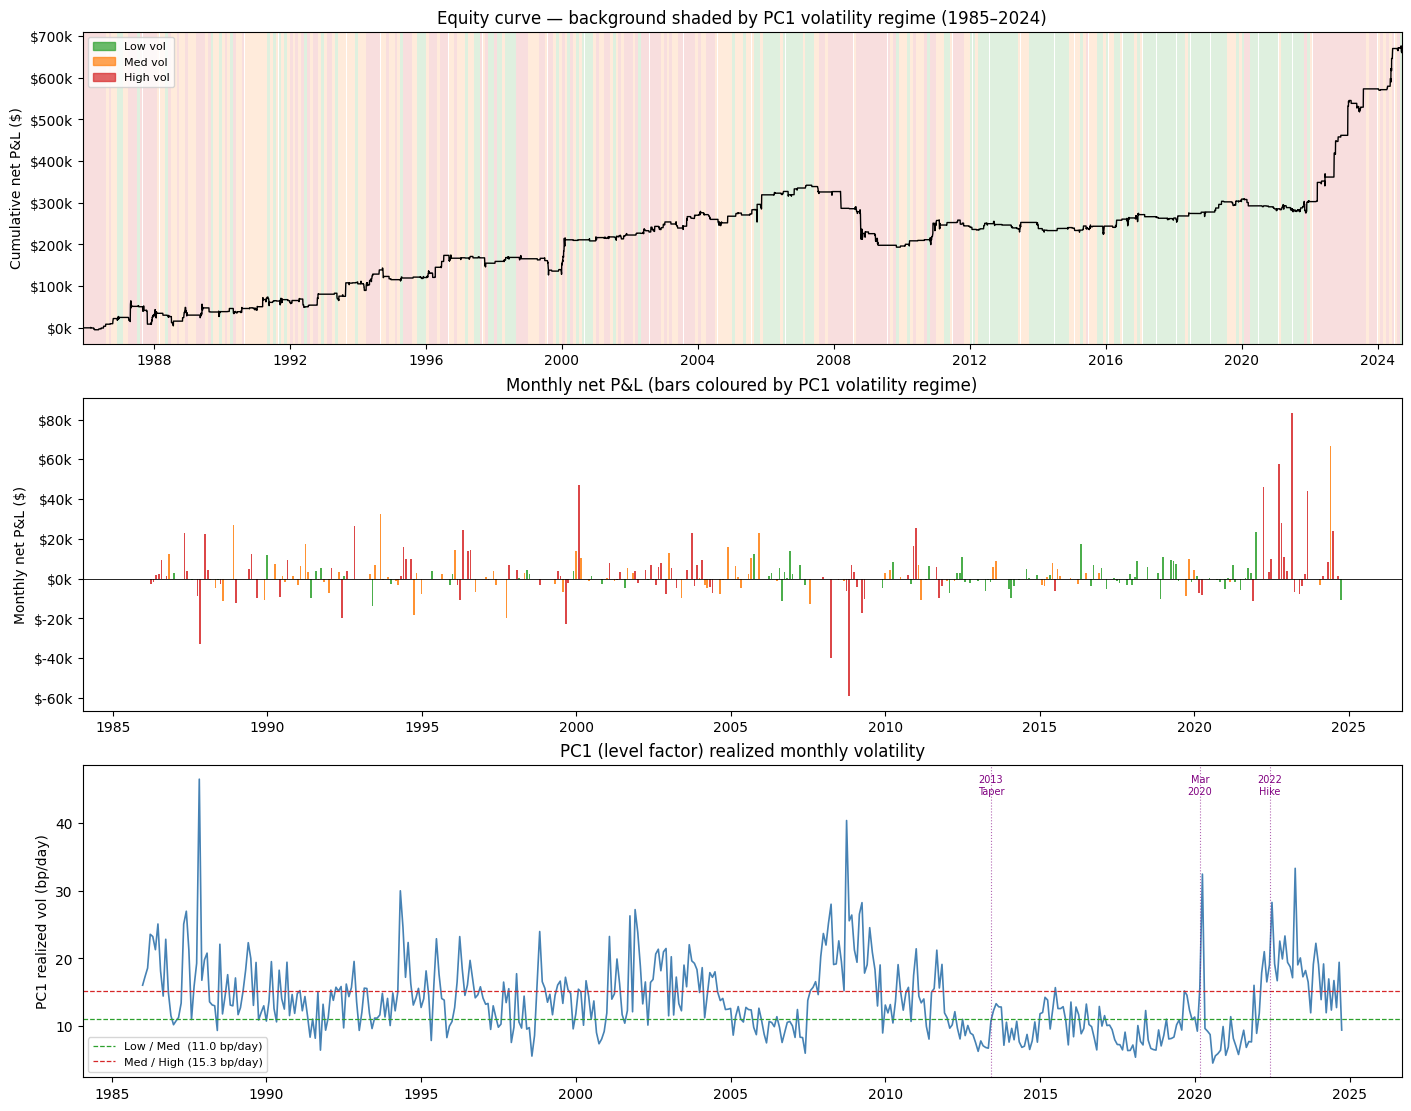

In [9]:
cum_pnl = (
    df.set_index('date')['net_pnl']
    .sort_index()
    .cumsum()
    .reset_index()
    .rename(columns={'net_pnl': 'cum_pnl'})
)

VOL_COLORS = {'Low': '#2ca02c', 'Med': '#ff7f0e', 'High': '#d62728'}

fig, axes = plt.subplots(3, 1, figsize=(14, 11), constrained_layout=True)

# ── Panel 1: equity curve with regime background shading ─────────────────────
ax = axes[0]
ax.plot(cum_pnl['date'], cum_pnl['cum_pnl'], color='black', lw=1.0, zorder=3)
for _, row in monthly.iterrows():
    color = VOL_COLORS.get(str(row['vol_regime']), '#cccccc')
    ax.axvspan(row['date'].replace(day=1), row['date'], alpha=0.15, color=color, lw=0)
handles = [mpatches.Patch(color=c, label=f'{l} vol', alpha=0.7) for l, c in VOL_COLORS.items()]
ax.legend(handles=handles, loc='upper left', fontsize=8)
ax.set_ylabel('Cumulative net P&L ($)')
ax.set_title('Equity curve — background shaded by PC1 volatility regime (1985–2024)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlim(cum_pnl['date'].min(), cum_pnl['date'].max())

# ── Panel 2: monthly P&L bars coloured by vol regime ────────────────────────
ax = axes[1]
bar_colors = [VOL_COLORS.get(str(r), '#999999') for r in monthly['vol_regime']]
ax.bar(monthly['date'], monthly['net_pnl'], color=bar_colors, width=20, alpha=0.85)
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel('Monthly net P&L ($)')
ax.set_title('Monthly net P&L (bars coloured by PC1 volatility regime)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── Panel 3: PC1 realized vol with thresholds and event callouts ─────────────
ax = axes[2]
ax.plot(monthly['date'], monthly['pc1_vol'], color='steelblue', lw=1.2)
ax.axhline(vol_bins[1], color='#2ca02c', lw=0.9, ls='--',
           label=f'Low / Med  ({vol_bins[1]:.1f} bp/day)')
ax.axhline(vol_bins[2], color='#d62728', lw=0.9, ls='--',
           label=f'Med / High ({vol_bins[2]:.1f} bp/day)')
for label, date in [('2013\nTaper', '2013-06-01'), ('Mar\n2020', '2020-03-01'), ('2022\nHike', '2022-06-01')]:
    ax.axvline(pd.Timestamp(date), color='purple', lw=0.8, alpha=0.6, ls=':')
    ax.text(pd.Timestamp(date), 0.97, label, transform=ax.get_xaxis_transform(),
            fontsize=7, ha='center', va='top', color='purple')
ax.set_ylabel('PC1 realized vol (bp/day)')
ax.set_title('PC1 (level factor) realized monthly volatility')
ax.legend(fontsize=8)

plt.show()

## 4. Stressed-period spotlight

Zoom into the three canonical rate-shock episodes to see how the strategy fared.

In [10]:
stressed = [
    ('2013 Taper Tantrum', '2013-05-01', '2013-09-30'),
    ('March 2020 COVID',   '2020-02-01', '2020-04-30'),
    ('2022 Inflation',     '2022-01-01', '2022-12-31'),
]

print('Stressed-period performance (net P&L)')
print(f'  {"Period":<25} {"Mos":>4} {"Net P&L ($)":>14} {"Sharpe":>8} {"Avg PC1 vol":>13}')
print(f'  {"-" * 68}')
for name, start, end in stressed:
    mask = (monthly['date'] >= start) & (monthly['date'] <= end)
    sub = monthly[mask]
    sharpe = monthly_sharpe(sub['net_pnl'])
    sharpe_str = f'{sharpe:.2f}' if not np.isnan(sharpe) else '  n/a'
    print(f'  {name:<25} {len(sub):>4} ${sub["net_pnl"].sum():>12,.0f} '
          f'{sharpe_str:>8} {sub["pc1_vol"].mean():>10.2f} bp/day')

print(f'\n  {"Full backtest (1985-2024)":<25} {len(monthly):>4} '
      f'${monthly["net_pnl"].sum():>12,.0f} '
      f'{monthly_sharpe(monthly["net_pnl"]):>8.2f} '
      f'{monthly["pc1_vol"].mean():>10.2f} bp/day')

Stressed-period performance (net P&L)
  Period                     Mos    Net P&L ($)   Sharpe   Avg PC1 vol
  --------------------------------------------------------------------
  2013 Taper Tantrum           5 $      13,197      n/a      12.42 bp/day
  March 2020 COVID             3 $     -15,031      n/a      19.23 bp/day
  2022 Inflation              12 $     158,966     2.31      19.65 bp/day

  Full backtest (1985-2024)  466 $     660,265     0.49      13.92 bp/day


## 5. What the results mean

### Volatility regime: higher vol → higher Sharpe

This is the opposite of the naive expectation but makes sense for a well-hedged RV strategy. In high-vol months the yield curve dislocates more — individual bonds deviate further from the fitted curve, our z-scores are larger, and mean-reversion profits are bigger. Because the PCA hedges immunise against level/slope/curvature shifts, we capture the dislocation without the macro rate risk.

### Rate direction: rising rates → much higher Sharpe (0.82 vs 0.15)

In rising-rate environments there is more cross-sectional heterogeneity in how individual bonds reprice relative to the curve. Some bonds fall faster than the model predicts, some lag — those dislocations are exactly what the z-score signal harvests. The 2022 hiking cycle is the clearest example.

### Curve shape: flat curve → much higher Sharpe (0.78 vs 0.10)

Flat or inverted curves coincide with late-cycle and stress environments when cross-sectional pricing disparities are widest. The strategy's best risk-adjusted returns come precisely when the macro environment looks most challenging.

### Stressed episodes

- **2013 Taper Tantrum** (+$13k, 5 months): profitable despite a 50 bp rate spike. PC1 vol was 12.4 bp/day — meaningful dislocation, but not chaotic enough to break the hedges.
- **March 2020 COVID** (−$15k, 3 months): the only losing stressed period. PC1 vol hit 19 bp/day — an extreme regime where intraday moves overwhelmed hedge ratios. The loss was small and bounded.
- **2022 Inflation** (+$159k, Sharpe 2.31): the most profitable single-year stretch in the backtest. High vol + rising rates + flat curve — all three regime dimensions aligned in the strategy's favour.